# Buscaminas MARIE - Notebook autosuficiente

Este notebook:

1. genera un tablero de Buscaminas 16×16,
2. genera una **máscara de forma** (`SHAPE_PRESET`) para cambiar la forma del tablero,
3. crea los archivos:
   - `marie/generados/buscaminas_generado_mod.mas`
   - `marie/generados/tablero_marie_generado.mem`
   - `marie/generados/shape_preset_generado.mem`
   - `outputs/vista_tablero_buscaminas.png`
4. deja todo listo para abrir el `.mas` en **Marie.js**.

Está pensado para funcionar tanto en **Google Colab** como en **local**.


In [8]:
import os
import random
import requests
from pathlib import Path
from typing import List, Tuple, Optional

try:
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
except ImportError:
    !pip install -q matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap

# Crear estructura de carpetas
Path("marie/plantillas").mkdir(parents=True, exist_ok=True)
Path("marie/generados").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

print("✅ Entorno preparado.")

✅ Entorno preparado.


## Parámetros del tablero y de la forma
Modifica esta celda para cambiar minas, semilla y forma.

In [9]:
# Configuración del tablero
FILAS = 16
COLUMNAS = 16
MINAS = 30
SEMILLA = 23 # Cambia esto para obtener tableros diferentes

# Forma del tablero: "llena", "rombo", "cruz", "marco"
FORMA = "llena"

# URL de respaldo para la plantilla (Ajusta con tu usuario de GitHub)
URL_PLANTILLA_RAW = "https://raw.githubusercontent.com/maateonicolas/buscaminas-marie/main/marie/plantillas/buscaminas_template_mod.mas"

In [10]:
def generar_tablero_completo(f, c, n_minas, semilla):
    random.seed(semilla)
    tablero = [[0 for _ in range(c)] for _ in range(f)]

    # Colocar minas
    colocadas = 0
    while colocadas < n_minas:
        rf, rc = random.randint(0, f-1), random.randint(0, c-1)
        if tablero[rf][rc] != -1:
            tablero[rf][rc] = -1
            colocadas += 1

    # Calcular adyacencias
    for i in range(f):
        for j in range(c):
            if tablero[i][j] == -1: continue
            minas_cerca = 0
            for df in [-1,0,1]:
                for dc in [-1,0,1]:
                    if 0 <= i+df < f and 0 <= j+dc < c:
                        if tablero[i+df][j+dc] == -1: minas_cerca += 1
            tablero[i][j] = minas_cerca
    return tablero

def calcular_mapa_regiones(tablero, f, c):
    """
    Calcula grupos de celdas que deben revelarse juntas.
    ID 0 significa que no pertenece a ninguna región de expansión (es una mina o número aislado).
    """
    region_map = [[0 for _ in range(c)] for _ in range(f)]
    visitado = set()
    current_id = 1

    for i in range(f):
        for j in range(c):
            if tablero[i][j] == 0 and (i, j) not in visitado:
                cola = [(i, j)]
                visitado.add((i, j))
                while cola:
                    curr_f, curr_c = cola.pop(0)
                    region_map[curr_f][curr_c] = current_id
                    for df in [-1,0,1]:
                        for dc in [-1,0,1]:
                            nf, nc = curr_f+df, curr_c+dc
                            if 0 <= nf < f and 0 <= nc < c:
                                if tablero[nf][nc] == 0 and (nf, nc) not in visitado:
                                    visitado.add((nf, nc))
                                    cola.append((nf, nc))
                                elif tablero[nf][nc] > 0:
                                    region_map[nf][nc] = current_id
                current_id += 1
    return region_map

def matriz_a_marie_dec(matriz):
    lineal = [val for fila in matriz for val in fila]
    return "\n".join([f"    DEC {v}" for v in lineal])

print("✅ Funciones de lógica definidas.")

✅ Funciones de lógica definidas.


In [11]:
import requests
from pathlib import Path

# URLs posibles (GitHub usa 'main' por defecto ahora, pero muchos repos antiguos usan 'master')
URL_MAIN = "https://raw.githubusercontent.com/maateonicolas/buscaminas-marie/main/marie/plantillas/buscaminas_template_mod.mas"
URL_MASTER = "https://raw.githubusercontent.com/maateonicolas/buscaminas-marie/master/marie/plantillas/buscaminas_template_mod.mas"

import requests
import os
from pathlib import Path

# Configuración de rutas para local y GitHub
REPO_RAW_URL = "https://raw.githubusercontent.com/maateonicolas/buscaminas-marie/main/marie/plantillas/buscaminas_template_mod.mas"

def obtener_plantilla_maestra():
    # 1. Intentar encontrar el archivo en la raíz (si ejecutas desde el root)
    ruta_root = Path("marie/plantillas/buscaminas_template_mod.mas")
    # 2. Intentar encontrar el archivo subiendo un nivel (si ejecutas desde notebooks/)
    ruta_notebook = Path("../marie/plantillas/buscaminas_template_mod.mas")

    plantilla = None

    if ruta_root.exists():
        print(f"✅ Archivo encontrado en raíz: {ruta_root}")
        plantilla = ruta_root.read_text(encoding="utf-8")
    elif ruta_notebook.exists():
        print(f"✅ Archivo encontrado subiendo un nivel: {ruta_notebook}")
        plantilla = ruta_notebook.read_text(encoding="utf-8")
    else:
        print("🌐 No se encontró el archivo local. Descargando de GitHub...")
        try:
            r = requests.get(REPO_RAW_URL)
            if r.status_code == 200:
                plantilla = r.text
                print("✅ Descarga de GitHub exitosa.")
        except Exception as e:
            print(f"❌ Error de red: {e}")

    return plantilla

# Forzamos la actualización de la variable global
template_mas = obtener_plantilla_maestra()

# VALIDACIÓN CRÍTICA: Si el mapa no se actualiza, es porque faltan estos marcadores
if template_mas and "__TABLERO_REAL__" not in template_mas:
    print("🚨 ADVERTENCIA: La plantilla cargada NO tiene los marcadores __TABLERO_REAL__.")
    print("Asegúrate de que tu archivo 'buscaminas_template_mod.mas' sea la versión V6.")

✅ Archivo encontrado subiendo un nivel: ..\marie\plantillas\buscaminas_template_mod.mas


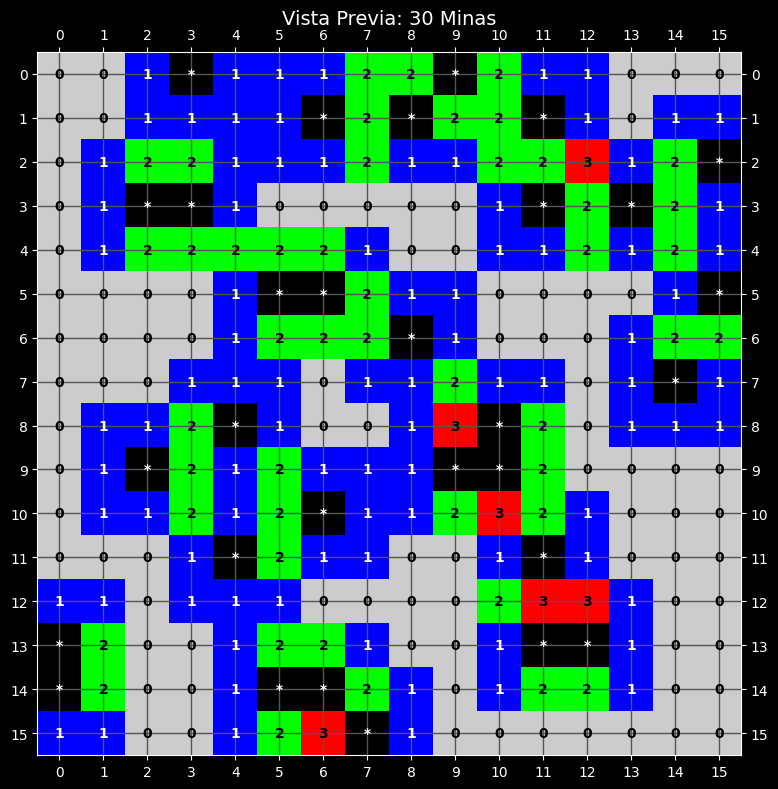

In [12]:
# Generar datos
tablero = generar_tablero_completo(FILAS, COLUMNAS, MINAS, SEMILLA)
regiones = calcular_mapa_regiones(tablero, FILAS, COLUMNAS)
shape = [[1 for _ in range(COLUMNAS)] for _ in range(FILAS)] # Tablero lleno

# --- PREPARAR MATRIZ PARA DIBUJAR ---
# Convertimos el -1 (mina) en 9 para que coincida con el color negro del cmap
matriz_visual = []
for i in range(FILAS):
    fila_vis = []
    for j in range(COLUMNAS):
        if shape[i][j] == 0:
            fila_vis.append(10) # 10 = fuera de forma
        else:
            valor = tablero[i][j]
            if valor == -1:
                fila_vis.append(9) # 9 = mina
            else:
                fila_vis.append(valor) # 0 al 8
    matriz_visual.append(fila_vis)

# --- CONFIGURACIÓN DE COLORES ---
cmap = ListedColormap([
    "#CCCCCC",  # 0: gris claro
    "#0000FF",  # 1: azul
    "#00FF00",  # 2: verde
    "#FF0000",  # 3: rojo
    "#0000AA",  # 4: azul oscuro
    "#880000",  # 5: rojo oscuro
    "#00FFFF",  # 6: cian (turquesa)
    "#AA00FF",  # 7: violeta
    "#FFFFFF",  # 8: blanco
    "#000000",  # 9: mina: negro
    "#222222",  # 10: fuera de forma: gris oscuro
])

# --- DIBUJAR TABLERO ---
plt.figure(figsize=(8, 8))
# Ahora sí usamos 'cmap=cmap' y forzamos la escala de 0 a 10
plt.imshow(matriz_visual, cmap=cmap, vmin=0, vmax=10)

for i in range(FILAS):
    for j in range(COLUMNAS):
        if shape[i][j] == 0:
            continue # Si está fuera de forma no dibujamos texto

        valor = tablero[i][j]
        txt = "*" if valor == -1 else str(valor)

        # Alto contraste: letra blanca en fondos oscuros (minas, 1, 4, 5)
        color_texto = "white" if valor in [-1, 1, 4, 5] else "black"

        plt.text(j, i, txt, ha="center", va="center", color=color_texto, fontweight="bold")

plt.title(f"Vista Previa: {MINAS} Minas", fontsize=14, pad=20)

# --- ESCALA EN LOS 4 LADOS ---
plt.xticks(range(COLUMNAS))
plt.yticks(range(FILAS))
plt.tick_params(
    top=True, bottom=True, left=True, right=True,
    labeltop=True, labelbottom=True, labelleft=True, labelright=True
)

# Cuadrícula para separar bien las celdas
plt.grid(True, which="both", color="#555555", linewidth=1)

plt.tight_layout()
plt.savefig("outputs/vista_tablero_buscaminas.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
def exportar_proyecto(template, tablero, shape, regiones, destino):
    # 1. Reemplazar los marcadores con las matrices nuevas
    content = template.replace("__TABLERO_REAL__", matriz_a_marie_dec(tablero))
    content = content.replace("__SHAPE_PRESET__", matriz_a_marie_dec(shape))
    content = content.replace("__REGION_MAP__", matriz_a_marie_dec(regiones))

    # 2. Asegurar que la carpeta exista
    import os
    from pathlib import Path
    Path(destino).parent.mkdir(parents=True, exist_ok=True)

    # 3. Guardar el archivo en el entorno actual
    with open(destino, "w", encoding="utf-8") as f:
        f.write(content)
    print(f"🚀 Archivo generado y guardado en: {destino}")

    # 4. Magia para Google Colab: Forzar la descarga automática al navegador
    try:
        from google.colab import files
        files.download(destino)
        print("📥 ¡Descarga automática iniciada! Abre ESTE nuevo archivo en Marie.js")
    except ImportError:
        print("💻 Modo Local: El archivo ya está en tu disco. Abre la carpeta 'marie/generados/'")

# Ejecutar la exportación
exportar_proyecto(
    template_mas,
    tablero,
    shape,
    regiones,
    "marie/generados/buscaminas_generado_mod.mas"
)

🚀 Archivo generado y guardado en: marie/generados/buscaminas_generado_mod.mas
💻 Modo Local: El archivo ya está en tu disco. Abre la carpeta 'marie/generados/'
